In [1314]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Personal Finance Tracker: Analyzing My Own Finances

This project is a personal finance analysis I conducted to better understand my spending, saving, and income patterns.

**Goals of this project:**
- Track income and expenses over several months.
- Identify patterns in spending habits.
- Visualize and compare financial trends.
- Improve decision-making and budgeting in the future.

In [1316]:
# Importing my budget data to pandas.
financial_log = pd.concat(
    pd.read_excel("C:/Users/jeesh/Desktop/Financial Budget.xlsx", 
                  sheet_name=None, 
                  parse_dates=["Date"], 
                  usecols=["Date", "Category", "Description", "Income", "Expense"], #Selecting columns to import
                  dtype={"Category":"string", "Description": "string", "Income":"float32", "Expense":"float32"}
                 )
    , ignore_index=True)
# Changing date datatype for memory optimization
financial_log["Date"] = pd.to_datetime(financial_log["Date"])
financial_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         331 non-null    datetime64[ns]
 1   Category     331 non-null    string        
 2   Description  331 non-null    string        
 3   Income       54 non-null     float32       
 4   Expense      276 non-null    float32       
dtypes: datetime64[ns](1), float32(2), string(2)
memory usage: 10.5 KB


## Data Loading & Cleaning

The dataset was manually tracked and includes:
- `Date`: When the transaction occurred
- `Description`: Short note about the transaction
- `Category`: Income, Rent, Food, etc.
- `Expense` and `Income`: Separated columns
- Derived fields like: `Month`, `Day of Week`, `Running Totals`, etc.

**Cleaning steps:**
- Parsed the `Date` column to datetime format
- Filtered and separated income from expenses
- Added calculated columns for `Running Total`, `Half of Month`, and `Savings`


The dataset used in this project is based on my personal financial records, which I’ve been consistently tracking since **October 2024**. Over time, I’ve refined my logging system by introducing additional columns and more detailed spending categories to better understand my financial habits.

This analysis focuses on data from **October 2024 to April 2025**. While there are newer columns that could offer deeper insights, I've chosen not to include them here to maintain consistency across the dataset. Future versions of this project may incorporate those enhancements.

> *Note: All numbers and descriptions shown have been anonymized for privacy, but the structure of the data remains the same.*

In [1319]:
##### The numbers have been scaled by a factor of x and the description has been edited for privacy.
# scaling_factor = x
# financial_log["Expense"] = financial_log["Expense"] * scaling_factor
# financial_log["Income"] = financial_log["Income"] * scaling_factor
financial_log["Description"] = financial_log["Description"].apply(lambda x: "Private Entry")
financial_log

,Date,Category,Description,Income,Expense
0,2024-10-01,Food,Private Entry,NaN,9.020000
1,2024-10-01,Food,Private Entry,NaN,1.920000
2,2024-10-02,Food,Private Entry,NaN,1.700000
3,2024-10-02,Food,Private Entry,NaN,1.670000
4,2024-10-02,Other,Private Entry,NaN,2.120000
...,...,...,...,...,...
326,2025-04-30,Food,Private Entry,NaN,13.090000
327,2025-04-30,Groceries,Private Entry,NaN,10.760000
328,2025-04-30,Food,Private Entry,NaN,3.290000
329,2025-04-30,Groceries,Private Entry,NaN,28.860001


In [1320]:
#Code to check the integrity of the data imported,
april_data = financial_log.loc[
    (financial_log["Date"].dt.year == 2025) &
    (financial_log["Date"].dt.month == 4)
]
april_data

,Date,Category,Description,Income,Expense
266,2025-04-01,Groceries,Private Entry,NaN,11.530000
267,2025-04-01,Transportation,Private Entry,NaN,41.000000
268,2025-04-01,Income,Private Entry,1156.689941,NaN
269,2025-04-01,Transportation,Private Entry,NaN,4.000000
270,2025-04-02,Other,Private Entry,NaN,300.000000
...,...,...,...,...,...
326,2025-04-30,Food,Private Entry,NaN,13.090000
327,2025-04-30,Groceries,Private Entry,NaN,10.760000
328,2025-04-30,Food,Private Entry,NaN,3.290000
329,2025-04-30,Groceries,Private Entry,NaN,28.860001


In [1321]:
# Add Month and Year columns
financial_log["Month"] = financial_log["Date"].dt.to_period("M")

# Replace missing values
financial_log = financial_log.fillna({"Income": 0})
financial_log = financial_log.fillna({"Expense": 0})

#Adding running totals columns
financial_log["Running Total Income"] = financial_log["Income"].cumsum()
financial_log["Running Total Expense"] = financial_log["Expense"].cumsum()
financial_log["Running Balance"] = financial_log["Running Total Income"] - financial_log["Running Total Expense"]

#Adding a day column.
financial_log["Day"] = financial_log["Date"].dt.day_name()

financial_log

,Date,Category,Description,Income,Expense,Month,Running Total Income,Running Total Expense,Running Balance,Day
0,2024-10-01,Food,Private Entry,0.0,9.020000,2024-10,0.000000,9.020000,-9.020000,Tuesday
1,2024-10-01,Food,Private Entry,0.0,1.920000,2024-10,0.000000,10.940001,-10.940001,Tuesday
2,2024-10-02,Food,Private Entry,0.0,1.700000,2024-10,0.000000,12.640000,-12.640000,Wednesday
3,2024-10-02,Food,Private Entry,0.0,1.670000,2024-10,0.000000,14.310000,-14.310000,Wednesday
4,2024-10-02,Other,Private Entry,0.0,2.120000,2024-10,0.000000,16.430000,-16.430000,Wednesday
...,...,...,...,...,...,...,...,...,...,...
326,2025-04-30,Food,Private Entry,0.0,13.090000,2025-04,17723.949219,13397.624023,4326.325195,Wednesday
327,2025-04-30,Groceries,Private Entry,0.0,10.760000,2025-04,17723.949219,13408.383789,4315.565430,Wednesday
328,2025-04-30,Food,Private Entry,0.0,3.290000,2025-04,17723.949219,13411.673828,4312.275391,Wednesday
329,2025-04-30,Groceries,Private Entry,0.0,28.860001,2025-04,17723.949219,13440.534180,4283.415039,Wednesday


In [1322]:
#Total expenditure by Category
category_total = financial_log.groupby('Category')[['Expense']].sum().sort_values("Expense", ascending=False)
category_total = category_total.drop("Income", axis=0)
category_total = category_total.reset_index()
category_total

,Category,Expense
0,Other,2546.500000
1,Rent,2500.000000
2,Transportation,2274.800049
3,Car Insurance,1830.000000
4,Groceries,1759.920044
5,Food,1225.290039
6,Personal Care,566.440002
7,Subscriptions,399.180023
8,Entertainment,338.399994


## Visual Insights:

### Total Expenditure by Category Breakdown
This bar plot shows where my money flows categorically. This chart helps me identify where I spent my money from October to April. 

> Insight: Most of money is spent on fixed funds like rent, insurance and gas. *Other* category represent the things that cannot be put into other categories like gifts, investments and etc. It's clear that I can reduce the amount of money I spend on eating out.


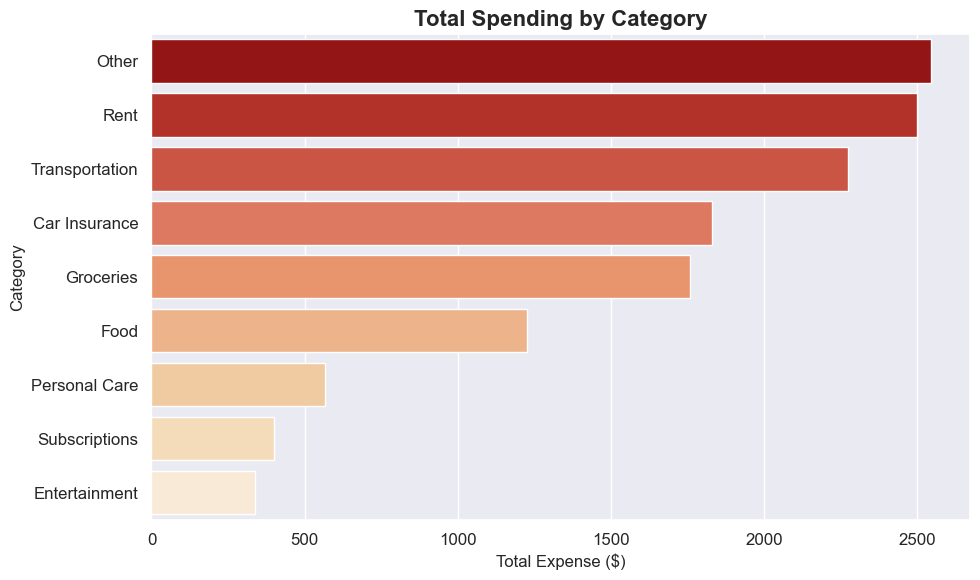

In [1324]:
sns.set_theme(style="darkgrid", font_scale=1.1) #Using the darkgrid theme for the chart.

plt.figure(figsize=(10, 6))
#Using seaborn and matplotlib to plot all the charts in this project
ax = sns.barplot( 
    data=category_total,
    x="Expense",
    y="Category",
    hue="Category",
    palette="OrRd_r" 
)

# Adding labels and title
ax.set_title("Total Spending by Category", fontsize=16, weight='bold')
ax.set_xlabel("Total Expense ($)", fontsize=12)
ax.set_ylabel("Category", fontsize=12)

plt.tight_layout() #This prevents form text/graphs flowing out of the chart.
plt.show()

In [1325]:
#Mean of expenditure by Category
category_mean = financial_log.groupby('Category')[['Expense']].mean().sort_values("Expense", ascending=False)
category_mean = category_mean.drop("Income", axis=0)
category_mean

,Expense
Category,
Rent,416.666656
Car Insurance,305.000000
Other,74.897057
Groceries,51.762356
Transportation,48.400002
Personal Care,40.459999
Entertainment,19.905882
Subscriptions,14.784446
Food,13.318370


## Visual Insights:

### Avg Expenditure by Category Breakdown
This bar plot shows where my money flows categorically. This chart helps me identify *how much on average* I spent my money from October to April in different categories. 

> Insight: Most of money is spent on fixed funds like rent, insurance and gas. *Other* category represent the things that cannot be put into other categories like gifts, investments and etc. This chart made me realize that even though I don't spend as much money on food, a significant amount of money has gone towards food as seen in the previous chart. I compared both the graphs side-by-side to get better insights.

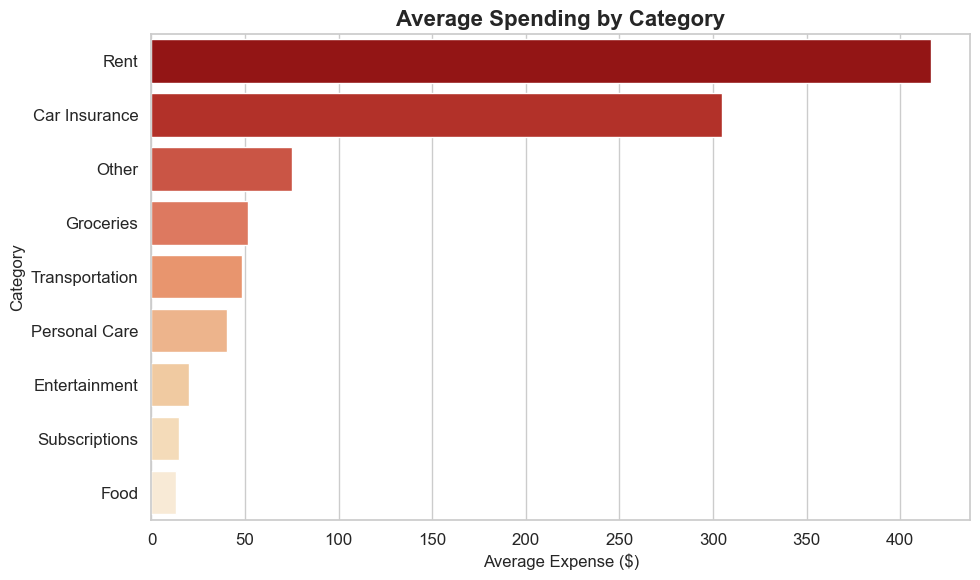

In [1327]:
sns.set_theme(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=category_mean,
    x="Expense",
    y="Category",
    hue="Category",
    palette="OrRd_r",
)

# Adding labels and title
ax.set_title("Average Spending by Category", fontsize=16, weight='bold')
ax.set_xlabel("Average Expense ($)", fontsize=12)
ax.set_ylabel("Category", fontsize=12)

plt.tight_layout()
plt.show()


## Visual Insights:

### Avg Expenditure by Category Breakdown
This bar plot shows where my money flows categorically. This chart helps me identify *how much on average* and *how much in total* I spent my money from October to April in different categories. 

#### Key Insights:
>**1.One key observation from this analysis is that small, recurring expenses such as, those under the Food, Entertainment, and Subscription categories accumulate significantly over time.**
>
>**2.Individually, most transactions in these categories are relatively low (often under $10), especially subscriptions. However, the frequency of these transactions causes them to add up quickly, resulting in a notable share of my total monthly expenses.**
>
>**3.This highlights how minor spending habits can have a major long-term financial impact, even when they seem negligible at the moment. As seen in the food category**

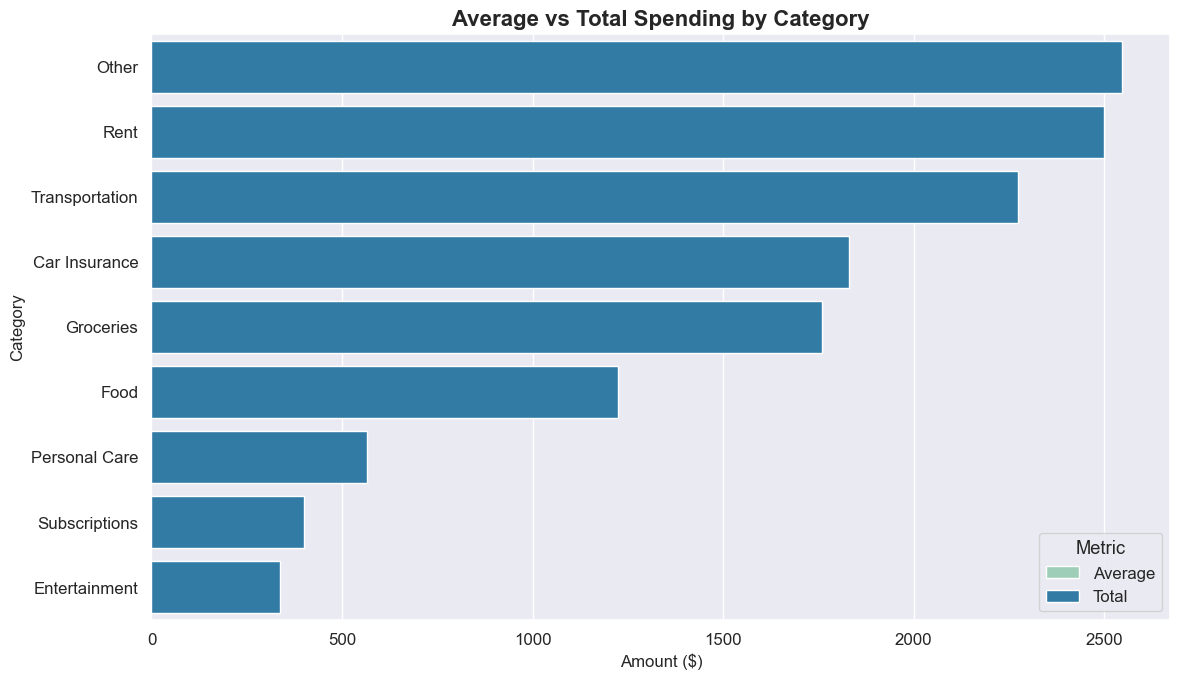

In [1329]:
# Add a column to distinguish them
category_mean['Type'] = 'Average'
category_total['Type'] = 'Total'

# Rename the value column to match
category_mean.rename(columns={"Expense": "Amount"}, inplace=True)
category_total.rename(columns={"Expense": "Amount"}, inplace=True)

# Combine into one DataFrame
combined = pd.concat([category_mean, category_total])

sns.set_theme(style="darkgrid", font_scale=1.1)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=combined,
    x="Amount",
    y="Category",
    hue="Type",
    palette="YlGnBu"
)

# Add title and labels
ax.set_title("Average vs Total Spending by Category", fontsize=16, weight='bold')
ax.set_xlabel("Amount ($)", fontsize=12)
ax.set_ylabel("Category", fontsize=12)

    
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [1330]:
#Total monthly expense
monthly_expense = financial_log.groupby("Month")[["Expense"]].sum()
monthly_expense = monthly_expense.sort_values("Expense", ascending=True)
monthly_expense

,Expense
Month,
2024-10,893.809998
2024-11,1216.300049
2025-03,1580.859985
2024-12,1770.150024
2025-04,2509.399902
2025-01,2581.229980
2025-02,2888.780029


In [1331]:
#Avg monthly expense
avg_monthly_expense = financial_log.groupby("Month")[["Expense"]].mean()
avg_monthly_expense

,Expense
Month,
2024-10,18.241020
2024-11,40.543335
2024-12,40.230682
2025-01,44.503963
2025-02,64.195114
2025-03,39.521500
2025-04,38.606152


## Visual Insights:

### Total Monthly Expense
This bar-graph represents the total money I have spent in each of the months. 

> Insights: February '25 is an outlier here. Due to some personal reasons, my transportation expenses scaled up quite high this month which is reflected in the graph.

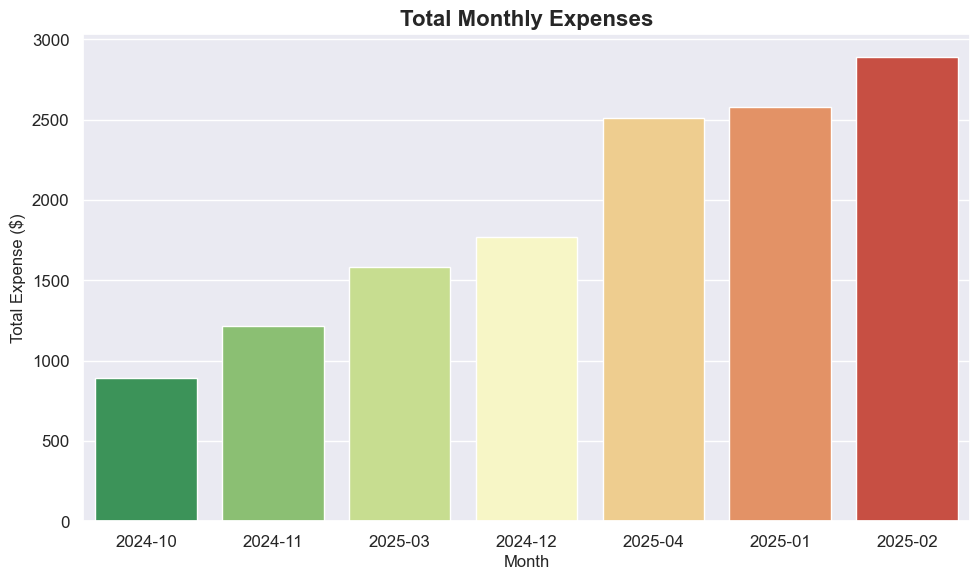

In [1333]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=monthly_expense,
    x="Month",
    y="Expense",
    hue="Month",
    palette="RdYlGn_r"
)

# Add titles and labels
ax.set_title("Total Monthly Expenses", fontsize=16, weight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Total Expense ($)", fontsize=12)

plt.tight_layout()
plt.show()

In [1334]:
#Total monthly income
monthly_income = financial_log.groupby("Month")[["Income"]].sum()
monthly_income

,Income
Month,
2024-10,1453.000000
2024-11,1908.150024
2024-12,2096.399902
2025-01,2757.979980
2025-02,2716.140137
2025-03,2003.659912
2025-04,4978.620117


In [1335]:
#Monthly summary of total income, total expenditure and total savings
monthly_summary = pd.concat([monthly_income, monthly_expense], axis=1)
monthly_summary["Savings"] = monthly_summary["Income"] - monthly_summary["Expense"]
monthly_summary

,Income,Expense,Savings
Month,,,
2024-10,1453.000000,893.809998,559.190002
2024-11,1908.150024,1216.300049,691.849976
2024-12,2096.399902,1770.150024,326.249878
2025-01,2757.979980,2581.229980,176.750000
2025-02,2716.140137,2888.780029,-172.639893
2025-03,2003.659912,1580.859985,422.799927
2025-04,4978.620117,2509.399902,2469.220215


## Visual Insights:

### Budget Summary
This bar-graph represents the total money that I have spent, earned and saved throught these months. A side-by-side comparison helps with analysis.

#### Key Insights:
> **1. My income has been increasing steadily throught overtime with a big jump in April. Which reflects that my new job helped with the income.**
> 
> **2. My expenses remained relatively stable from October to January, peaked in February, and then dropped sharply in March (To increase savings), staying lower through April.**
> 
> **3. April was my best savings month and February was the worst. Savings were rebounded in March which helped me recover financially.**

<Axes: title={'center': 'Budget Summary'}, xlabel='Month', ylabel='Amount ($)'>

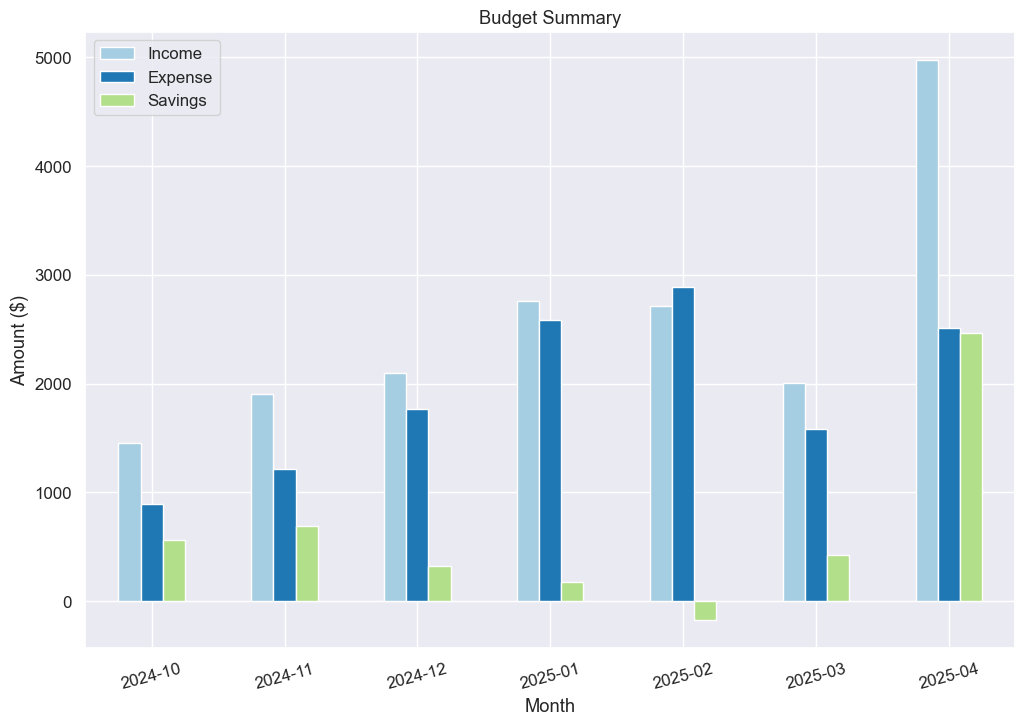

In [1337]:
monthly_summary.reset_index()
sns.set_theme(style="darkgrid", font_scale=1.1, palette="Paired",)
monthly_summary.plot.bar(figsize =(12, 8),
    title="Budget Summary",
    xlabel="Month",
    ylabel="Amount ($)",
    rot=15
)

In [1338]:
#Total Monthly Expenditure by Category
monthly_total_expenditure_by_category = (financial_log
                                   .groupby(['Month', 'Category'], as_index = False)
                                   .agg(total_expenditure = ("Expense", "sum")
                                       )
                                  )
i = monthly_total_expenditure_by_category[monthly_total_expenditure_by_category.Category == "Income"].index
monthly_total_expenditure_by_category = monthly_total_expenditure_by_category.drop( i, axis = 0)
monthly_total_expenditure_by_category
monthly_total_expenditure_by_category[(monthly_total_expenditure_by_category["Category"] == "Subscriptions") | (monthly_total_expenditure_by_category["Category"] == "Groceries")]

,Month,Category,total_expenditure
2,2024-10,Groceries,45.270000
9,2024-11,Groceries,270.230011
14,2024-11,Subscriptions,18.070000
18,2024-12,Groceries,163.030014
22,2024-12,Subscriptions,41.619999
27,2025-01,Groceries,228.949997
32,2025-01,Subscriptions,102.250000
37,2025-02,Groceries,302.299988
42,2025-02,Subscriptions,37.280003
47,2025-03,Groceries,321.540009


## Visual Insights:

### Total Monthly Expenditure by Category
This bar-graph represents the where and how much money I spent throught October to April, categorically.

#### Key Insights:
> **1.My expenditure on groceries has increased significantly. Consequently, I eat out less often. This is represented in the next bar graph below.**
> 
> **2.My overall subscription expenses are low but have been slowly growing since October to April**
> 
> **3.Personal and entertainment expenses have remained steady, this indicates disciplined spending :)**
>
> **4.Transportation expenses have increased overall since I own a car now**

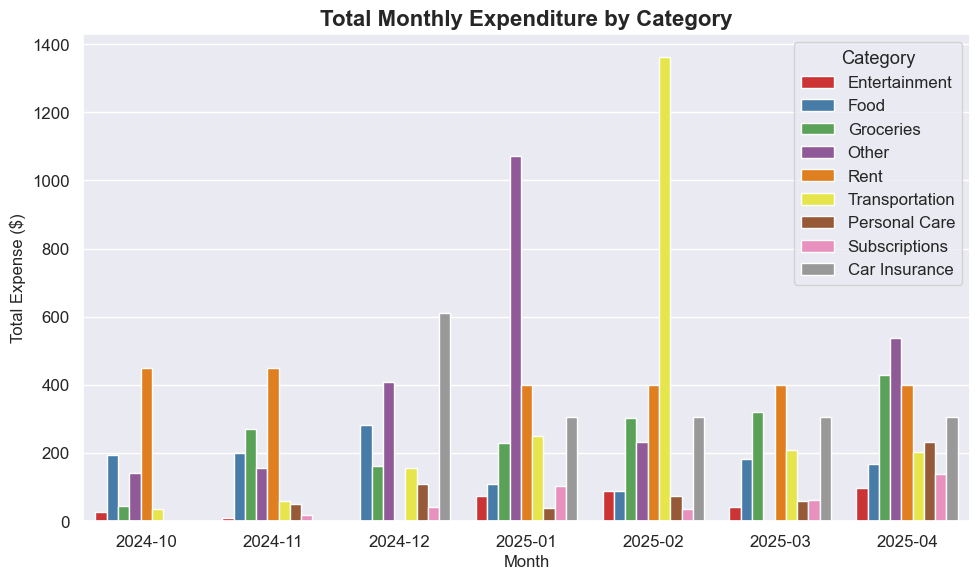

In [1404]:
monthly_total_expenditure_by_category.reset_index()
sns.set_theme(style="darkgrid", font_scale=1.1, palette="Set1",)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=monthly_total_expenditure_by_category,
    x="Month",
    y="total_expenditure",
    hue="Category",
) 

ax.set_title("Total Monthly Expenditure by Category", fontsize=16, weight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Total Expense ($)", fontsize=12)

plt.tight_layout()
plt.show()

## Visual Insights:

### Expenditure on Groceries and Eating out
This bar-graph represents how much I spend on groceries and eating out monthly.

>Insights: Though, my grocery expenses have increased and I eat out less often, the money spent on eating out in April is pretty much the same as October. Indicating dietry changes. 

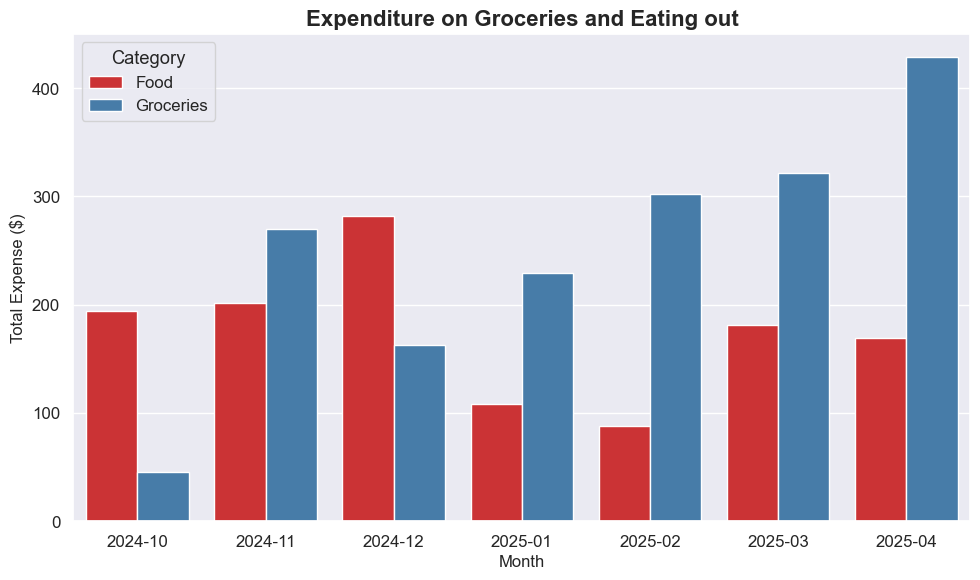

In [1406]:
#Relation between eating out and groceries
monthly_total_expenditure_by_category.reset_index()
sns.set_theme(style="darkgrid", font_scale=1.1, palette="Set1",)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=monthly_total_expenditure_by_category[
    (monthly_total_expenditure_by_category["Category"] == "Groceries")| 
    (monthly_total_expenditure_by_category["Category"] == "Food")],
    x="Month",
    y="total_expenditure",
    hue="Category"
) 

ax.set_title("Expenditure on Groceries and Eating out", fontsize=16, weight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Total Expense ($)", fontsize=12)

plt.tight_layout()
plt.show()

In [1343]:
# Average Monthly Expenditure
monthly_avg_expenditure_by_category = (financial_log
                                   .groupby(['Month', 'Category'], as_index = False)
                                   .agg(avg_expenditure = ("Expense", "mean")
                                       )
                                  )
i = monthly_avg_expenditure_by_category[monthly_avg_expenditure_by_category.Category == "Income"].index
monthly_avg_expenditure_by_category = monthly_avg_expenditure_by_category.drop( i, axis = 0)
monthly_avg_expenditure_by_category

,Month,Category,avg_expenditure
0,2024-10,Entertainment,12.900000
1,2024-10,Food,6.950000
2,2024-10,Groceries,45.270000
4,2024-10,Other,12.824546
5,2024-10,Rent,450.000000
6,2024-10,Transportation,9.267500
7,2024-11,Entertainment,9.030000
8,2024-11,Food,12.605000
9,2024-11,Groceries,90.076668
11,2024-11,Other,78.474998


In [1344]:
#Transaction count by days
expense_days = financial_log[financial_log["Expense"] > 0]
expense_day_counts = expense_days["Day"].value_counts()
expense_day_counts = expense_day_counts.to_frame()
expense_day_counts

,count
Day,
Tuesday,51
Wednesday,44
Friday,43
Thursday,41
Monday,41
Saturday,32
Sunday,24


## Visual Insights:

### Transaction count by Days
This bar-graph shows the days that I am most likely to spend.

>Insights: I was not aware of it but the day that has the highest transaction count is Tuesday. This makes complete sense because I work night shifts on the weekends. This is followed by Wednesday, Friday, Thursday and Monday (The days that I more likely to have an off). Hence, I am more likely to spend on the days that I don't work.

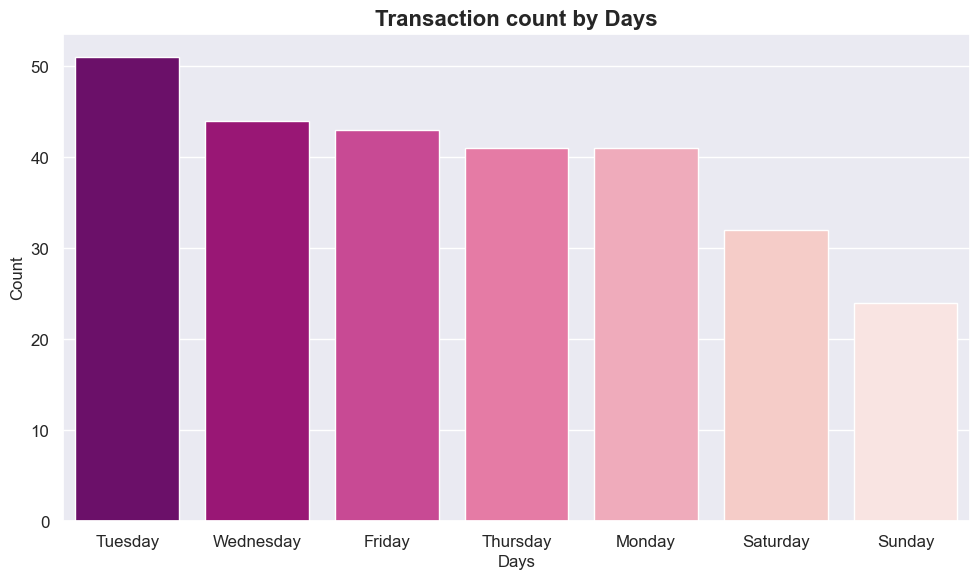

In [1410]:
expense_day_counts.reset_index()
sns.set_theme(style="darkgrid", font_scale=1.1)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=expense_day_counts,
    x="Day",
    y="count",
    hue="Day",
    palette="RdPu_r")

ax.set_title("Transaction count by Days", fontsize=16, weight="bold")
ax.set_xlabel("Days", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

In [1347]:
#Avg transaction by days
avg_expense_by_day = expense_days.groupby("Day")["Expense"].mean().sort_values(ascending=False)
avg_expense_by_day = avg_expense_by_day.to_frame()
avg_expense_by_day

,Expense
Day,
Sunday,78.392082
Saturday,64.654686
Wednesday,63.327271
Monday,54.691956
Tuesday,41.541763
Friday,34.748375
Thursday,20.697317


## Visual Insights:

### Average Expenditure by Days
This bar-graph shows the average amount that I spend each day.

>Insights: Even though I spend more often on Tuesdays, I spend more money per purchase on the weekends. This means that I make big purchases like groceries, refueling or partying on the weekends.

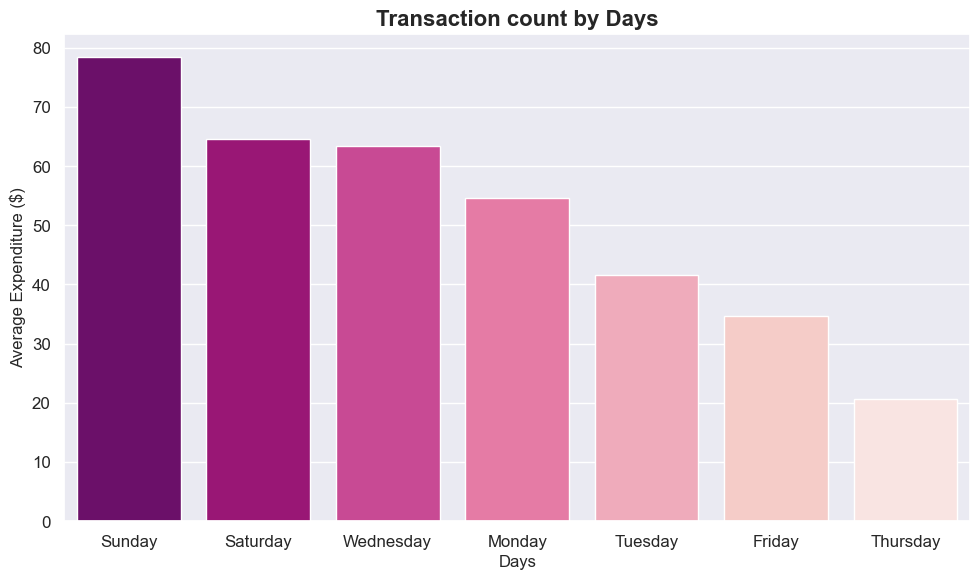

In [1414]:
avg_expense_by_day.reset_index()

sns.set_theme(style="darkgrid", font_scale=1.1)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=avg_expense_by_day,
    x="Day",
    y="Expense",
    hue="Day",
    palette="RdPu_r")

ax.set_title("Transaction count by Days", fontsize=16, weight="bold")
ax.set_xlabel("Days", fontsize=12)
ax.set_ylabel("Average Expenditure ($)", fontsize=12)

plt.tight_layout()
plt.show()


## Visual Insights:

### Comparing the above two graphs side-by-side
This chart compares the above two graphs side-by-side

>Insights: While most of my transactions occur on my off-days like Tuesdays and Wednesdays, the highest average spending happens on Sundays and Saturdays, typically when I’m working. This suggests I make more frequent but smaller purchases on days off, and larger, possibly automated or planned purchases during the weekend. It highlights how spending behavior varies not just by time, but by intent and routine.

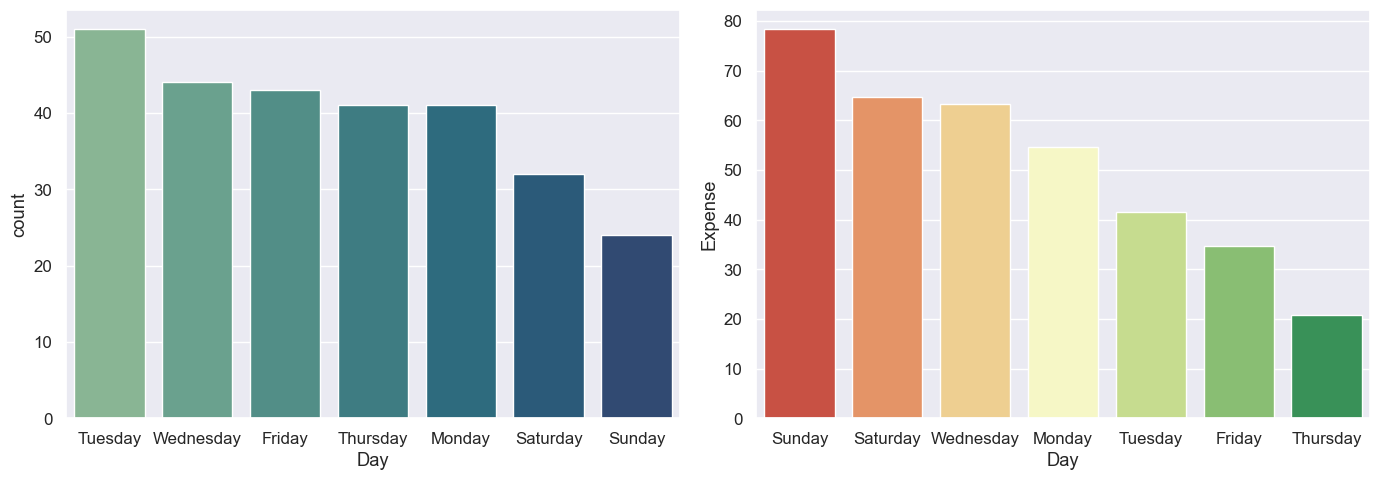

In [1351]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

ax = sns.barplot(
    data=expense_day_counts,
    x="Day",
    y="count",
    hue="Day",
    palette="crest",
    ax=axs[0])

ax = sns.barplot(
    data=avg_expense_by_day,
    x="Day",
    y="Expense",
    hue="Day",
    palette="RdYlGn",
    ax=axs[1])

plt.tight_layout()
plt.show()

## Verification of the data:
I examined whether I tend to buy groceries, refuel, eat out, or go out more often on weekends — and found that isn't the case. These types of transactions actually happen more frequently on my off-days during the week. However, the data shows that when I do spend on weekends, the amount per transaction is significantly higher. This suggests that I make larger, bulk purchases on weekends — such as stocking up on groceries or handling bigger errands — even if the number of transactions is lower.

In [1353]:
#The days that I eat out
cons = financial_log["Category"] == "Food"
financial_log.loc[cons, "Day"].value_counts()

Day
Tuesday      22
Thursday     17
Wednesday    15
Monday       15
Saturday     10
Sunday        7
Friday        6
Name: count, dtype: int64

In [1354]:
#The days that I go out to buy groceries
cons = financial_log["Category"] == "Groceries"
financial_log.loc[cons, "Day"].value_counts()

Day
Wednesday    7
Tuesday      7
Monday       7
Sunday       4
Saturday     4
Friday       3
Thursday     2
Name: count, dtype: int64

In [1355]:
#The days that spend money on transportation (Refueling or car accessories)
cons = financial_log["Category"] == "Transportation"
financial_log.loc[cons, "Day"].value_counts()

Day
Tuesday      10
Saturday      9
Wednesday     8
Friday        6
Sunday        5
Monday        5
Thursday      4
Name: count, dtype: int64

In [1356]:
#The days that I buy personal items (Clothes, haircuts and etc)
cons = financial_log["Category"] == "Personal Care"
financial_log.loc[cons, "Day"].value_counts()

Day
Thursday     5
Tuesday      3
Friday       3
Saturday     2
Wednesday    1
Name: count, dtype: int64

In [1357]:
#The days that I spend on entertainment (Buying games, gaming accessories or going to an arcade)
cons = financial_log["Category"] == "Entertainment"
financial_log.loc[cons, "Day"].value_counts()

Day
Thursday     3
Saturday     3
Monday       3
Tuesday      3
Friday       2
Sunday       2
Wednesday    1
Name: count, dtype: int64

In [1358]:
#Avg Spending by first and second half of month
financial_log["HalfOfMonth"] = np.where(financial_log["Date"].dt.day <= 15, 
                                        "First Half", "Second Half")

expenses = financial_log[(financial_log["Expense"] > 0) & (financial_log["Category"] != "Rent") & (financial_log["Category"] != "Car Insurance")]
expenses_by_halves = expenses.groupby("HalfOfMonth")["Expense"].mean()
expenses_by_halves = expenses_by_halves.to_frame()
expenses_by_halves

,Expense
HalfOfMonth,
First Half,38.865036
Second Half,29.516748


## Visual Insights:

### Avg Spending by first and second half of month (Excluding Insurance and Rent)
This bar-graph shows the average amount that I spend during the first and the second half of the month.

>Insights: I am more likely to spend money during the first half of the month. The rest of month is often spent in trying to save up.

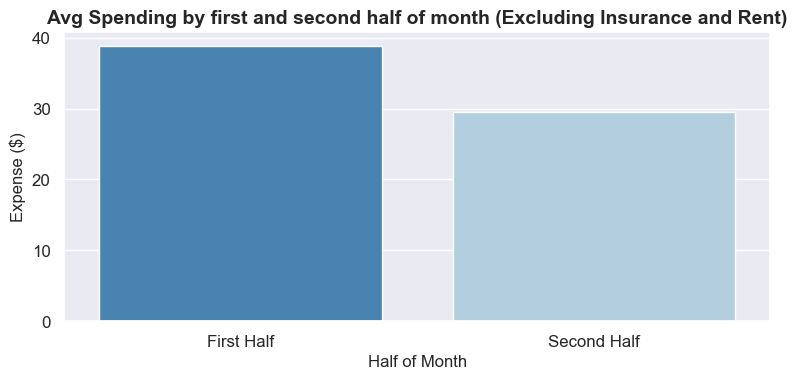

In [1421]:
expenses_by_halves.reset_index()
sns.set_theme(style="darkgrid", font_scale=1.1)
plt.figure(figsize=(8,4))
ax = sns.barplot(
    data=expenses_by_halves,
    x="HalfOfMonth",
    y="Expense",
    hue = "HalfOfMonth",
    palette="Blues_r")

ax.set_title("Avg Spending by first and second half of month (Excluding Insurance and Rent)", fontsize=14, weight="bold")
ax.set_xlabel("Half of Month", fontsize=12)
ax.set_ylabel("Expense ($)", fontsize=12)

plt.tight_layout()
plt.show()

In [1361]:
#Avg Earnings by first and second half of month
financial_log["HalfOfMonth"] = np.where(financial_log["Date"].dt.day <= 15, 
                                        "First Half", "Second Half")

expenses = financial_log[(financial_log["Income"] > 0)]
income_by_halves = expenses.groupby("HalfOfMonth")["Income"].mean()
income_by_halves = income_by_halves.to_frame()
income_by_halves

,Income
HalfOfMonth,
First Half,326.637878
Second Half,337.234222


## Visual Insights:

### Avg Earnings by first and second half of month
This bar-graph shows the average amount that I earn during the first and the second half of the month,

>Insights: On average, I earn more during the second half of the month compared to the first half.

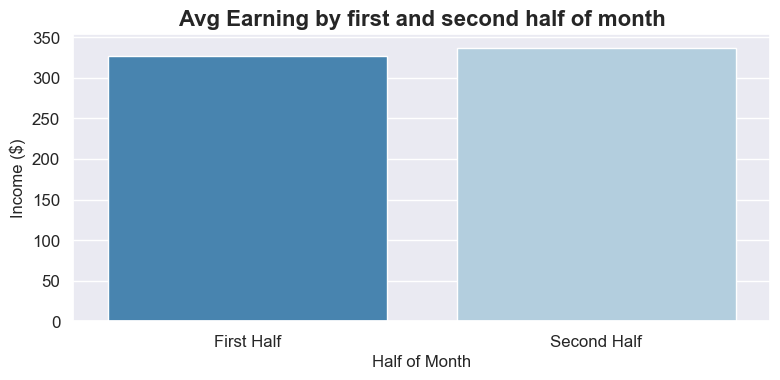

In [1425]:
income_by_halves.reset_index()
sns.set_theme(style="darkgrid", font_scale=1.1)
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=income_by_halves,
    x="HalfOfMonth",
    y="Income",
    hue = "HalfOfMonth",
    palette="Blues_r")


ax.set_title("Avg Earning by first and second half of month", fontsize=16, weight="bold")
ax.set_xlabel("Half of Month", fontsize=12)
ax.set_ylabel("Income ($)", fontsize=12)

plt.tight_layout()
plt.show()

## Visual Insights:

### Avg Earnings and spendings by first and second half of month (Excluding Insurance and Rent)
This bar-graph shows the average amount that I spend and earn during the first and the second half of the month, side-by-side

#### Key Insights: 
>**I tend to spend more during the first half of the month — likely fulfilling most of my needs upfront through bulk or essential purchases.**
>
>**As the month progresses, I become more financially aware and cautious, leading to reduced spending in the second half.**
>
>**Interestingly, despite spending less later in the month, I earn slightly more during the second half, which contributes to higher savings during that period.**

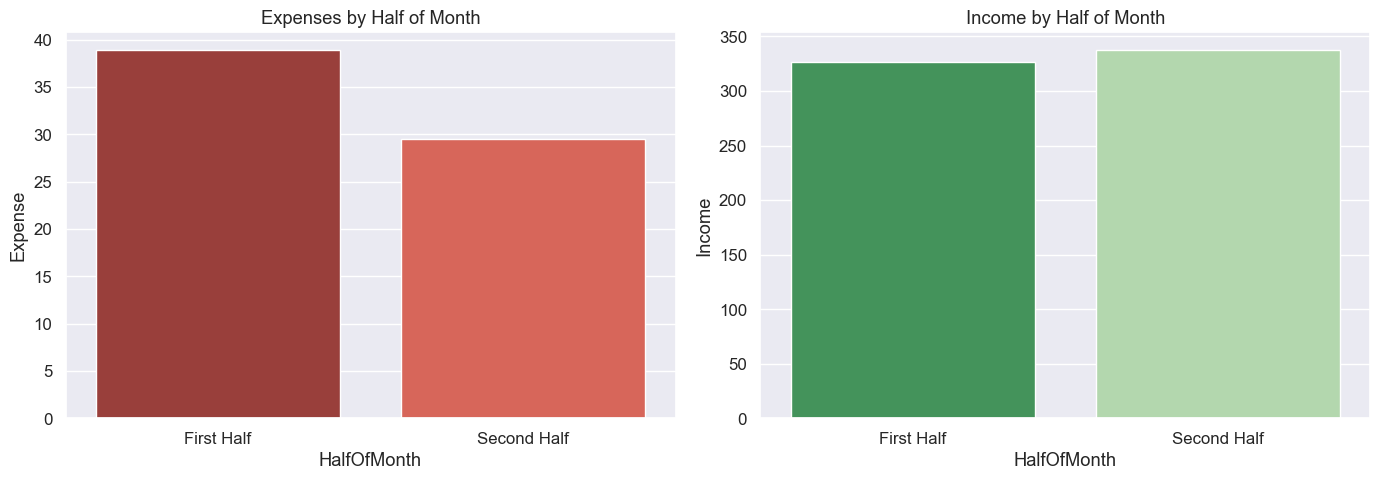

In [1365]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=expenses_by_halves,
    x="HalfOfMonth",
    y="Expense",
    hue= "HalfOfMonth",
    palette="Reds_r_d",
    ax=axs[0]
)
axs[0].set_title("Expenses by Half of Month")

sns.barplot(
    data=income_by_halves,
    x="HalfOfMonth",
    y="Income",
    hue= "HalfOfMonth",
    palette="Greens_r",
    ax=axs[1]
)
axs[1].set_title("Income by Half of Month")

plt.tight_layout()
plt.show()

## Visual Insights:

### Running Total, Running Expenses and Running Balance by Time
This line graph shows the growth in my overall wealth, expenditure and balance.

>Insights: Over time, both my Running Total Income and Running Total Expenses show a natural upward trend — this makes sense, as they accumulate month by month. However, what's particularly insightful is that my Running Balance (Income minus Expenses) remains relatively steady with a slight upward trend. This suggests that I'm consistently managing my expenses relative to what I earn and despite spending more over time (as expected with increasing income and life demands), I'm still able to maintain a positive balance, showing signs of financial discipline and improvement.

<Axes: title={'center': 'Running Total, Running Expenses and Running Balance by Time'}, xlabel='Amount ($)', ylabel='Month'>

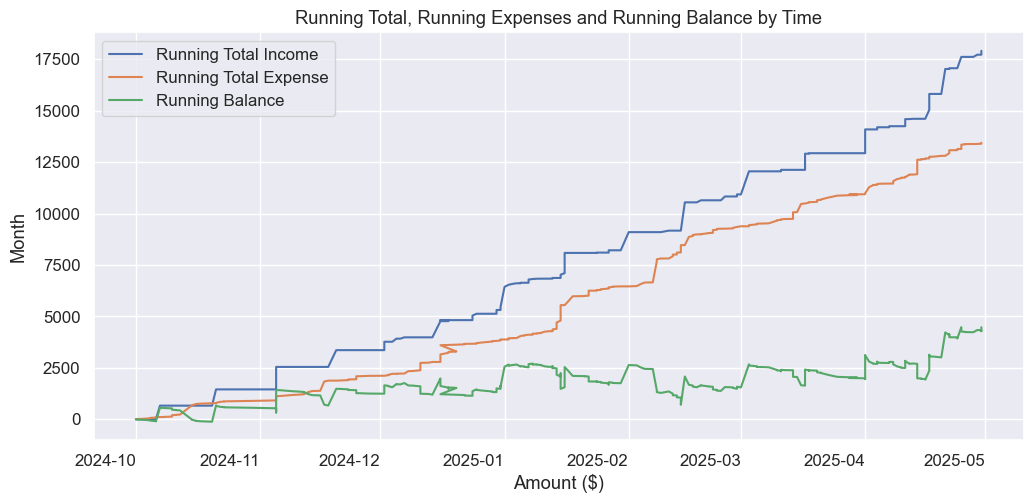

In [1431]:
sns.set_theme(style="darkgrid", font_scale=1.1)
financial_log.plot(x='Date', y=['Running Total Income', 'Running Total Expense', 'Running Balance'], 
                   figsize=(12,6), 
                   title="Running Total, Running Expenses and Running Balance by Time",
                   xlabel="Amount ($)",
                   ylabel="Month",
                   rot=0)